### 1-qism

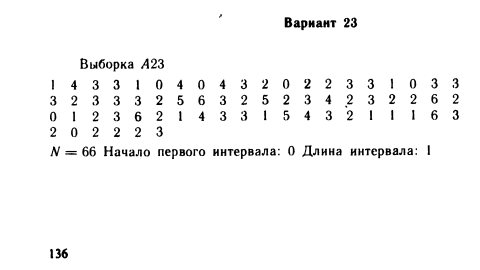

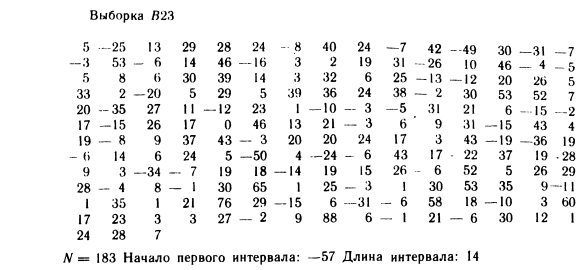

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

In [2]:
ser_a = pd.Series([1, 4, 3, 3, 1, 0, 4, 0, 4, 3, 2, 0, 2, 
                   2, 3, 3, 1, 0, 3, 3, 3, 2, 3, 3, 3, 2, 
                   5, 6, 3, 2, 5, 2, 3, 4, 2, 3, 2, 2, 6, 
                   2, 0, 1, 2, 3, 6, 2, 1, 4, 3, 3, 1, 5, 
                   4, 3, 2, 1, 1, 1, 6, 3, 2, 0, 2, 2, 2, 3])

ser_a.shape

(66,)

In [3]:
ser_b = pd.Series([5, -25, 13, 29, 28, 24, -8, 40, 24, -7, 42, -49, 30, -31, -7,
 -3, 53, -6, 14, 46, -16, 3, 2, 19, 31, -26, 10, 46, -4, -5,
 5, 8, 6, 30, 39, 14, 3, 32, 6, 25, -13, -12, 20, 26, 5,
 33, 2, -20, 5, 29, 5, 39, 36, 24, 38, -2, 30, 53, 52, 7,
 20, -35, 27, 11, -12, 23, 1, -10, -3, -5, 31, 21, 6, -15, -2,
 17, -15, 26, 17, 0, 46, 13, 21, -3, 6, 9, 31, -15, 43, 4,
 19, -8, 9, 37, 43, -3, 20, 20, 24, 17, 3, 43, -19, -36, 19,
 -6, 14, 6, 24, 5, -50, 4, -24, -6, 43, 17, 22, 37, 19, 28, 
 9, 3, -34, -7, 19, 18, -14, 19, 15, 26, -6, 52, 5, 26, 29,
 28, -4, 8, -1, 30, 65, 1, 25, -3, 1, 30, 53, 35, 9, -11,
 1, 35, 1, 21, 76, 29, -15, 6, -31, -6, 58, 18, -10, 3, 60,
 17, 23, 3, 3, 27, -2, 9, 88, 6, -1, 21, -6, 30, 12, 1, 24, 28, 7])
ser_b.shape

(183,)

In [4]:
bins = range(-57, int(ser_b.max()) + 15 , 14)
ser_b_int = pd.cut(ser_b, bins=bins)
ser_b_int

0        (-1, 13]
1      (-29, -15]
2        (-1, 13]
3        (27, 41]
4        (27, 41]
          ...    
178      (-1, 13]
179      (-1, 13]
180      (13, 27]
181      (27, 41]
182      (-1, 13]
Length: 183, dtype: category
Categories (11, interval[int64, right]): [(-57, -43] < (-43, -29] < (-29, -15] < (-15, -1] ... (41, 55] < (55, 69] < (69, 83] < (83, 97]]

variation series

In [5]:
var_a = ser_a.sort_values()
print(var_a)

7     0
5     0
11    0
17    0
61    0
     ..
30    5
27    6
38    6
58    6
44    6
Length: 66, dtype: int64


In [6]:
var_b = ser_b_int.sort_values()
print(var_b)

110    (-57, -43]
11     (-57, -43]
158    (-43, -29]
122    (-43, -29]
103    (-43, -29]
          ...    
164      (55, 69]
160      (55, 69]
140      (55, 69]
154      (69, 83]
172      (83, 97]
Length: 183, dtype: category
Categories (11, interval[int64, right]): [(-57, -43] < (-43, -29] < (-29, -15] < (-15, -1] ... (41, 55] < (55, 69] < (69, 83] < (83, 97]]


elative frequencies

In [7]:
table_a = var_a.value_counts().sort_index()
print(table_a)

0     6
1     9
2    18
3    20
4     6
5     3
6     4
Name: count, dtype: int64


In [8]:
table_b = var_b.value_counts().sort_index()
print(table_b)

(-57, -43]     2
(-43, -29]     5
(-29, -15]    10
(-15, -1]     32
(-1, 13]      46
(13, 27]      42
(27, 41]      28
(41, 55]      13
(55, 69]       3
(69, 83]       1
(83, 97]       1
Name: count, dtype: int64


In [9]:
int_midd_b = ser_b_int.apply(lambda x: x.mid)
int_midd_b

0       6.0
1     -22.0
2       6.0
3      34.0
4      34.0
       ... 
178     6.0
179     6.0
180    20.0
181    34.0
182     6.0
Length: 183, dtype: category
Categories (11, float64): [-50.0 < -36.0 < -22.0 < -8.0 ... 48.0 < 62.0 < 76.0 < 90.0]

In [10]:
rel_freq_a = table_a / var_a.shape[0]
rel_freq_a

0    0.090909
1    0.136364
2    0.272727
3    0.303030
4    0.090909
5    0.045455
6    0.060606
Name: count, dtype: float64

In [11]:
rel_freq_b = table_b / var_b.shape[0]
rel_freq_b

(-57, -43]    0.010929
(-43, -29]    0.027322
(-29, -15]    0.054645
(-15, -1]     0.174863
(-1, 13]      0.251366
(13, 27]      0.229508
(27, 41]      0.153005
(41, 55]      0.071038
(55, 69]      0.016393
(69, 83]      0.005464
(83, 97]      0.005464
Name: count, dtype: float64

cumulative frequencies

In [12]:
cum_rel_freq_a = rel_freq_a.cumsum()
cum_rel_freq_a

0    0.090909
1    0.227273
2    0.500000
3    0.803030
4    0.893939
5    0.939394
6    1.000000
Name: count, dtype: float64

In [13]:
cum_rel_freq_b = rel_freq_b.cumsum()
cum_rel_freq_b

(-57, -43]    0.010929
(-43, -29]    0.038251
(-29, -15]    0.092896
(-15, -1]     0.267760
(-1, 13]      0.519126
(13, 27]      0.748634
(27, 41]      0.901639
(41, 55]      0.972678
(55, 69]      0.989071
(69, 83]      0.994536
(83, 97]      1.000000
Name: count, dtype: float64

polygon of the variation series

Text(0, 0.5, 'frequency')

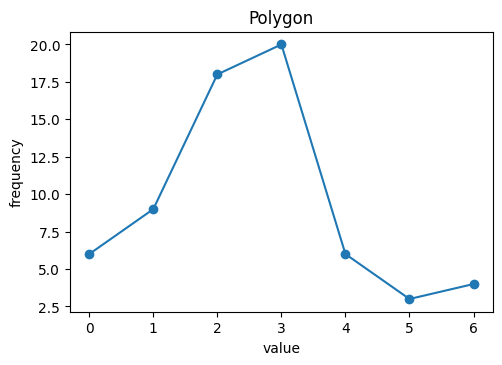

In [14]:
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(table_a.index, table_a.values, marker='o', linestyle='-')
plt.title("Polygon")
plt.xlabel("value")
plt.ylabel("frequency")

Text(0, 0.5, 'n_i (Frequency)')

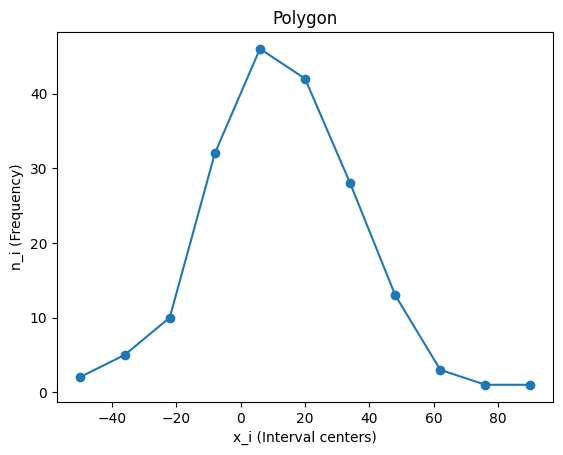

In [15]:
bin_centers = pd.Series([i.mid for i in table_b.index])
poly_plot = pd.Series(table_b.values, index=bin_centers).plot(kind='line', marker='o', title="Polygon")
poly_plot.set_xlabel("x_i (Interval centers)")
poly_plot.set_ylabel("n_i (Frequency)")

histogram of the variation series

Text(0.5, 1.0, 'Histogram')

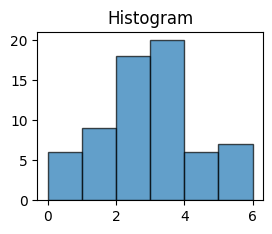

In [16]:
plt.subplot(2, 2, 2)
plt.hist(ser_a, bins='auto', edgecolor='black', alpha=0.7)
plt.title("Histogram")

Text(0, 0.5, 'n_i (Frequency)')

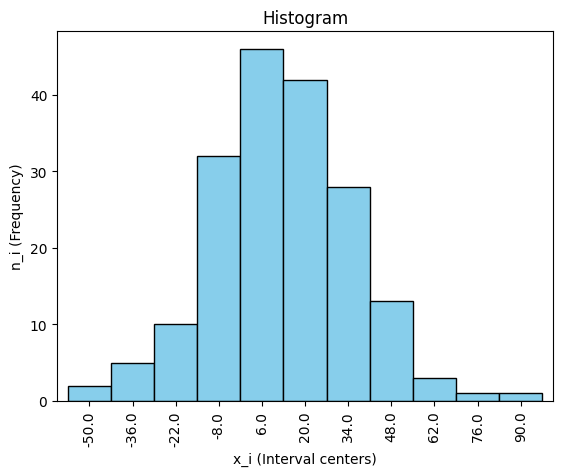

In [17]:
hist_plot = pd.Series(table_b.values, index=bin_centers).plot(kind='bar', width=1.0, color='skyblue', edgecolor='black', title="Histogram")
hist_plot.set_xlabel("x_i (Interval centers)")
hist_plot.set_ylabel("n_i (Frequency)")

empirical distribution function

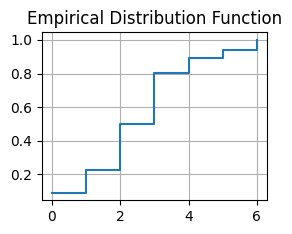

In [18]:
plt.subplot(2, 2, 3)
plt.step(table_a.index, cum_rel_freq_a.values, where='post')
plt.title("Empirical Distribution Function")
plt.grid(True)

Text(0, 0.5, 'F(x)')

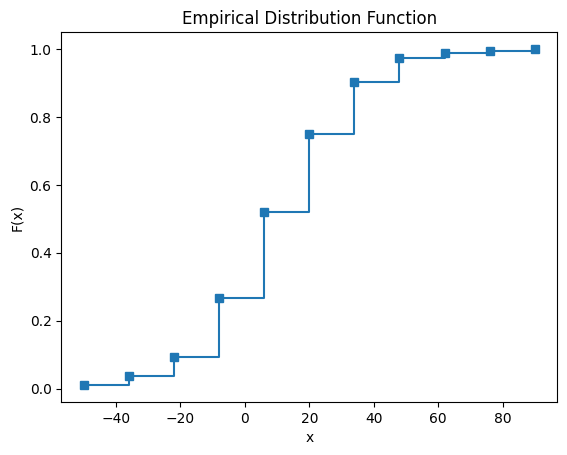

In [19]:
ecdf_plot = pd.Series(cum_rel_freq_b.values, index=bin_centers).plot(drawstyle='steps-post', marker='s', title="Empirical Distribution Function")
ecdf_plot.set_xlabel("x")
ecdf_plot.set_ylabel("F(x)")

sample mean

In [20]:
print(f"""
mean: {ser_a.mean()}
variance: {ser_a.var()}
standard deviation: {ser_a.std()}
mode: {ser_a.mode().values}
median: {ser_a.median()}
""")


mean: 2.5454545454545454
variance: 2.2825174825174823
standard deviation: 1.5108002788315478
mode: [3]
median: 2.5



In [21]:
print(f"""
mean: {ser_b.mean()}
variance: {ser_b.var()}
standard deviation: {ser_b.std()}
mode: {ser_b.mode().values}
median: {ser_b.median()}
""")


mean: 12.775956284153006
variance: 495.9550231189575
standard deviation: 22.270047667639993
mode: [3 5 6]
median: 11.0



### 2-qism

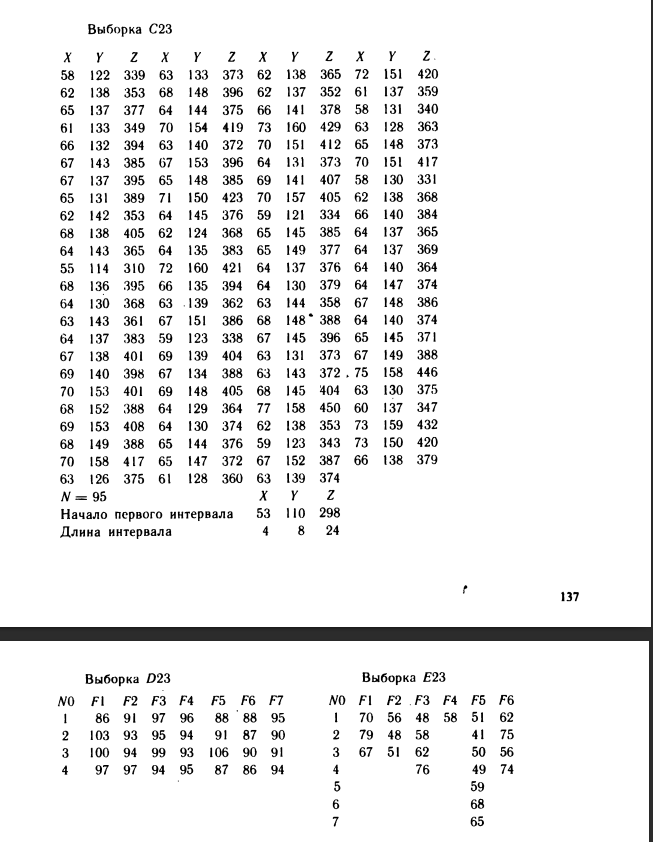

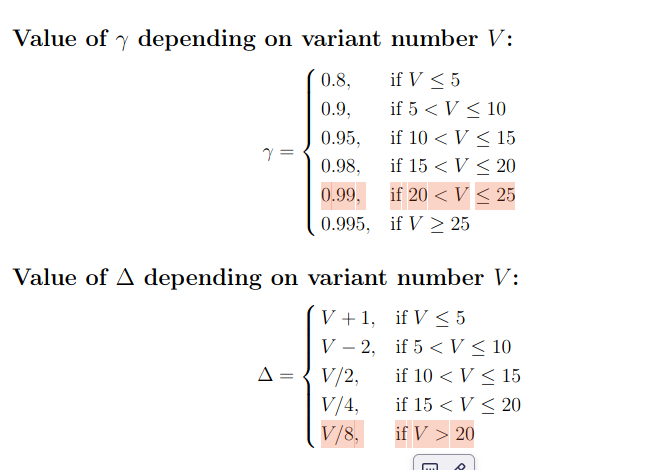

In [22]:
data = {
    'X': [
        58, 62, 65, 61, 66, 67, 67, 65, 62, 68, 64, 55, 68, 64, 63, 64, 67, 69, 70, 68, 69, 68, 70, 63,
        63, 68, 64, 70, 63, 67, 65, 71, 64, 62, 64, 72, 66, 63, 67, 59, 69, 67, 69, 64, 64, 65, 65, 61,
        62, 62, 66, 73, 70, 64, 69, 70, 59, 65, 65, 64, 64, 63, 68, 67, 63, 63, 68, 77, 62, 59, 67, 63,
        72, 61, 58, 63, 65, 70, 58, 62, 66, 64, 64, 64, 64, 67, 64, 65, 67, 75, 63, 60, 73, 73, 66
    ],
    'Y': [
        122, 138, 137, 133, 132, 143, 137, 131, 142, 138, 143, 114, 136, 130, 143, 137, 138, 140, 153, 152, 153, 149, 158, 126,
        133, 148, 144, 154, 140, 153, 148, 150, 145, 124, 135, 160, 135, 139, 151, 123, 139, 134, 148, 129, 130, 144, 147, 128,
        138, 137, 141, 160, 151, 131, 141, 157, 121, 145, 149, 137, 130, 144, 148, 145, 131, 143, 145, 158, 138, 123, 152, 139,
        151, 137, 131, 128, 148, 151, 130, 138, 140, 150, 137, 137, 140, 147, 148, 145, 149, 158, 130, 137, 159, 150, 138
    ],
    'Z': [
        339, 353, 377, 349, 394, 385, 395, 389, 353, 405, 365, 310, 395, 368, 361, 383, 401, 398, 401, 388, 408, 388, 417, 375,
        373, 396, 375, 419, 372, 396, 385, 423, 376, 368, 383, 421, 394, 362, 386, 338, 404, 388, 405, 364, 374, 376, 372, 360,
        365, 352, 378, 429, 412, 373, 407, 405, 334, 385, 377, 376, 379, 358, 388, 396, 373, 372, 404, 450, 353, 343, 387, 374,
        420, 359, 340, 363, 373, 417, 331, 368, 384, 365, 369, 364, 374, 386, 374, 371, 388, 446, 375, 347, 432, 420, 379
    ]
}


df_c = pd.DataFrame(data)
df_c.head()

,X,Y,Z
0,58,122,339
1,62,138,353
2,65,137,377
3,61,133,349
4,66,132,394


In [23]:
data = {
    'N0': [1, 2, 3, 4],
    'F1': [86, 103, 100, 97],
    'F2': [91, 93, 94, 97],
    'F3': [97, 95, 99, 94],
    'F4': [96, 94, 93, 95],
    'F5': [88, 91, 106, 87],
    'F6': [88, 87, 90, 86],
    'F7': [95, 90, 91, 94]
}

df_d = pd.DataFrame(data)
df_d.set_index('N0', inplace=True)
df_d.head()

,F1,F2,F3,F4,F5,F6,F7
N0,,,,,,,
1,86,91,97,96,88,88,95
2,103,93,95,94,91,87,90
3,100,94,99,93,106,90,91
4,97,97,94,95,87,86,94


For sample D, using the third and fourth columns (F3 and F4), find unbiased esti-
mates for the population mean μ, variance σ2, and standard deviation σ

In [24]:
print(f"""
mean: {df_d[["F3", "F4"]].mean()}
var: {df_d[["F3", "F4"]].var(ddof=1)}
std: {df_d[["F3", "F4"]].std(ddof=1)}
""")


mean: F3    96.25
F4    94.50
dtype: float64
var: F3    4.916667
F4    1.666667
dtype: float64
std: F3    2.217356
F4    1.290994
dtype: float64



or sample C, using the triple columns X, Y, Z, find unbiased estimates x, S2, and
S for the unknown population parameters.

In [25]:
print(f"""
X: 
    mean: {df_c['X'].mean()}
    var: {df_c['X'].var(ddof=1)}
    std: {df_c['X'].std(ddof=1)}
Y:
    mean: {df_c['Y'].mean()}
    var: {df_c['Y'].var(ddof=1)}
    std: {df_c['Y'].std(ddof=1)}
Z:
    mean: {df_c['Z'].mean()}
    var: {df_c['Z'].var(ddof=1)}
    std: {df_c['Z'].std(ddof=1)}
""")


X: 
    mean: 65.38947368421053
    var: 15.367973124300113
    std: 3.920200648474528
Y:
    mean: 140.93684210526317
    var: 96.31511758118695
    std: 9.814026573287181
Z:
    mean: 381.2842105263158
    var: 636.758790593505
    std: 25.23407994347139



For samples A and B corresponding to your variant, find confidence intervals for the
mean μ, variance σ2, and standard deviation σ with confidence probability γ

In [26]:
n = ser_a.shape[0]
gamma = 0.99 
mean_val = ser_a.mean()
s_var = ser_a.var(ddof=1)  
s_std = ser_a.std(ddof=1)  

t_val = stats.t.ppf((1 + gamma) / 2, n - 1)
margin_error = t_val * (s_std / np.sqrt(n))
ci_mean = (mean_val - margin_error, mean_val + margin_error)

chi2_low = stats.chi2.ppf((1 + gamma) / 2, n - 1)
chi2_high = stats.chi2.ppf((1 - gamma) / 2, n - 1)

ci_var = ((n - 1) * s_var / chi2_low, (n - 1) * s_var / chi2_high)

ci_std = (np.sqrt(ci_var[0]), np.sqrt(ci_var[1]))

print(f"Sample size (n): {n}")
print(f"Confidence level (gamma): {gamma}")
print(f"1. Mean interval: {ci_mean}")
print(f"2. Variance interval (sigma^2): {ci_var}")
print(f"3. Standard deviation interval (sigma): {ci_std}")

Sample size (n): 66
Confidence level (gamma): 0.99
1. Mean interval: (np.float64(2.0519725882588973), np.float64(3.0389365026501935))
2. Variance interval (sigma^2): (np.float64(1.5122921245540935), np.float64(3.7671864978834817))
3. Standard deviation interval (sigma): (np.float64(1.2297528713339496), np.float64(1.940924135014937))


In [27]:
n = ser_b.shape[0]
gamma = 0.99 
mean_val = ser_b.mean()
s_var = ser_b.var(ddof=1)  
s_std = ser_b.std(ddof=1)  

t_val = stats.t.ppf((1 + gamma) / 2, n - 1)
margin_error = t_val * (s_std / np.sqrt(n))
ci_mean = (mean_val - margin_error, mean_val + margin_error)

chi2_low = stats.chi2.ppf((1 + gamma) / 2, n - 1)
chi2_high = stats.chi2.ppf((1 - gamma) / 2, n - 1)

ci_var = ((n - 1) * s_var / chi2_low, (n - 1) * s_var / chi2_high)

ci_std = (np.sqrt(ci_var[0]), np.sqrt(ci_var[1]))

print(f"Sample size (n): {n}")
print(f"Confidence level (gamma): {gamma}")
print(f"1. Mean interval: {ci_mean}")
print(f"2. Variance interval (sigma^2): {ci_var}")
print(f"3. Standard deviation interval (sigma): {ci_std}")

Sample size (n): 183
Confidence level (gamma): 0.99
1. Mean interval: (np.float64(8.490584918109844), np.float64(17.06132765019617))
2. Variance interval (sigma^2): (np.float64(384.28016243596653), np.float64(660.7229733863788))
3. Standard deviation interval (sigma): (np.float64(19.603065128595745), np.float64(25.70453215653572))


Assuming that the data in samples A and B are taken for testing, determine the
minimum sample size n needed to find a confidence interval for the mean μ with
confidence probability γ and length 2∆

In [28]:
delta = 23 / 8  

z_gamma = stats.norm.ppf((1 + gamma) / 2)

s_std_a = ser_a.std(ddof=1)
n_min_a = (z_gamma * s_std_a / delta)**2

s_std_b = ser_b.std(ddof=1)
n_min_b = (z_gamma * s_std_b / delta)**2

print(f"Sample size (n) for A: {int(np.ceil(n_min_a))}")
print(f"Sample size (n) for B: {int(np.ceil(n_min_b))}")

Sample size (n) for A: 2
Sample size (n) for B: 399


### 3-qism

For sample A, test the hypothesis about the Poisson distribution.

In [29]:
lambda_est = ser_a.mean()

observed_counts = table_a.sort_index()
n_total = len(ser_a)

expected_probs = stats.poisson.pmf(observed_counts.index, lambda_est)

expected_probs = expected_probs / expected_probs.sum()

expected_counts = expected_probs * n_total

chi2_stat, p_value = stats.chisquare(f_obs=observed_counts, f_exp=expected_counts, ddof=1)

print("--- 1-task: Puasson distribution test ---")
print(f"Lambda (mean): {lambda_est:.4f}")
print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value > 0.01:
    print("Result: H0 is not rejected. The sample follows the Poisson distribution.")
else:
    print("Result: H0 is rejected. The sample does not follow the Poisson distribution.")

--- 1-task: Puasson distribution test ---
Lambda (mean): 2.5455
Chi-square statistic: 7.4808
p-value: 0.1873
Result: H0 is not rejected. The sample follows the Poisson distribution.


For sample B, test the hypothesis about the normal distribution.

In [30]:
stat_b, p_val_b = stats.shapiro(ser_b)

print("--- 2-task: Normal distribution test (Sample B) ---")
print(f"Shapiro-Wilk statistic: {stat_b:.4f}")
print(f"p-value: {p_val_b:.4f}")

if p_val_b > 0.01:
    print("Result: H0 is not rejected. The sample follows the Normal distribution.")
else:
    print("Result: H0 is rejected. The sample does not follow the Normal distribution.")

--- 2-task: Normal distribution test (Sample B) ---
Shapiro-Wilk statistic: 0.9908
p-value: 0.2878
Result: H0 is not rejected. The sample follows the Normal distribution.


 For the X column of sample C, test the hypothesis about the parameter α of the
normal distribution (with σ known and unknown)

In [31]:
x_data = df_c['X']
a0 = 16.0 
sigma_known = 1.0
z_stat = (x_data.mean() - a0) / (sigma_known / np.sqrt(len(x_data)))
p_val_z = 2 * (1 - stats.norm.cdf(abs(z_stat)))

t_stat, p_val_t = stats.ttest_1samp(x_data, a0)

print("\n--- 3-task: Mean (a) test (Column X) ---")
print(f"a) Variance known (Z-test) p-value: {p_val_z:.4f}")
print(f"b) Variance unknown (T-test) p-value: {p_val_t:.4f}")


--- 3-task: Mean (a) test (Column X) ---
a) Variance known (Z-test) p-value: 0.0000
b) Variance unknown (T-test) p-value: 0.0000


 For the Y column of sample C, test the hypothesis about the parameter σ of the
normal distribution (with α known and unknown)

In [32]:
y_data = df_c['Y']
sigma2_0 = 1.2 
n_c = len(y_data)
sample_var_y = y_data.var(ddof=1)

a_known = y_data.mean() 
chi2_stat_a = np.sum((y_data - a_known)**2) / sigma2_0
p_val_chi2_a = 1 - stats.chi2.cdf(chi2_stat_a, n_c)

chi2_stat_b = (n_c - 1) * sample_var_y / sigma2_0
p_val_chi2_b = 1 - stats.chi2.cdf(chi2_stat_b, n_c - 1)

print("\n--- 4-task: Variance (sigma^2) test (Column Y) ---")
print(f"Sample variance: {sample_var_y:.4f}")
print(f"a) a known p-value: {p_val_chi2_a:.4f}")
print(f"b) a unknown p-value: {p_val_chi2_b:.4f}")


--- 4-task: Variance (sigma^2) test (Column Y) ---
Sample variance: 96.3151
a) a known p-value: 0.0000
b) a unknown p-value: 0.0000
